## Image-Based Disease Detection Model

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Loading the Dataset

In [3]:
train_path = r"C:\Users\Admin\OneDrive\Desktop\Internship\chest_xray\train"
test_path  = r"C:\Users\Admin\OneDrive\Desktop\Internship\chest_xray\test"

## Data Preprocessing 

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Visualize Images

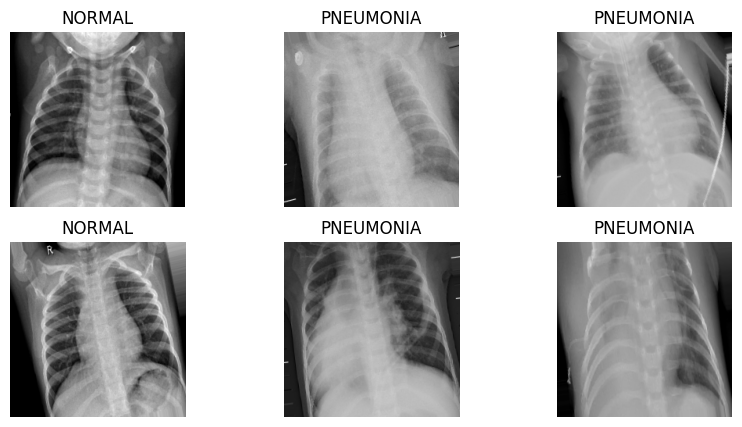

In [5]:
images, labels = next(train_data)

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title("PNEUMONIA" if labels[i]==1 else "NORMAL")

    plt.axis("off")

plt.show()

## Build DenseNet Model

In [6]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.3)(x)

prediction = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=prediction)

## Compile Model

In [7]:
model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 13,460,289 (51.35 MB)

 Trainable params: 6,422,785 (24.50 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Train Model

In [8]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 677s 4s/step - accuracy: 0.9114 - loss: 0.2431 - val_accuracy: 0.8285 - val_loss: 0.4396
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - accuracy: 0.9626 - loss: 0.1049 - val_accuracy: 0.8558 - val_loss: 0.3635
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 647s 4s/step - accuracy: 0.9630 - loss: 0.0959 - val_accuracy: 0.8606 - val_loss: 0.4035
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 906s 5s/step - accuracy: 0.9674 - loss: 0.0863 - val_accuracy: 0.8093 - val_loss: 0.5661
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 833s 5s/step - accuracy: 0.9743 - loss: 0.0733 - val_accuracy: 0.8590 - val_loss: 0.4173
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 854s 5s/step - accuracy: 0.9709 - loss: 0.0790 - val_accuracy: 0.8654 - val_loss: 0.4266
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 914s 5s/step - accuracy: 0.9745 - loss: 0.0718 - val_accuracy: 0.7708 - val_loss: 0.8825
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 930s 5s/step - accuracy: 0.9743 - loss: 0.0654 - val_accu

## Evaluate Model

In [9]:
pred_probs = model.predict(test_data)

pred = (pred_probs > 0.5).astype(int)

print(classification_report(test_data.classes, pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step
              precision    recall  f1-score   support

           0       0.99      0.61      0.75       234
           1       0.81      1.00      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



## Confusion Matrix

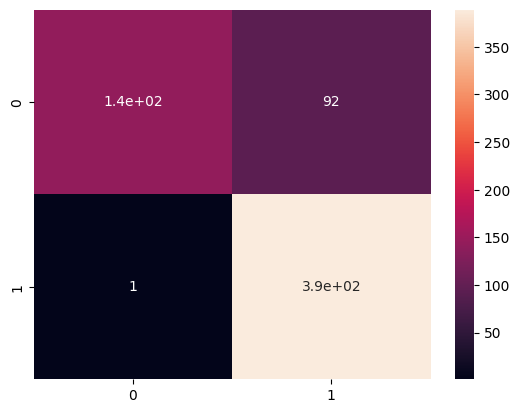

In [14]:
import seaborn as sns
cm = confusion_matrix(test_data.classes, pred)

sns.heatmap(cm, annot=True)

plt.show()

## ROC-AUC Score

In [15]:
auc = roc_auc_score(test_data.classes, pred_probs)

print("AUC Score:", auc)

AUC Score: 0.9680911680911681


## Save Model

In [17]:
model.save("pneumonia_model.h5")

In [20]:
!pip install tf-keras-vis


   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ---------------------------------------- 0/3 [imageio]
   ------------- -------------------------- 1/3 [deprecated]
   -------------------------- ------------- 2/3 [tf-keras-vis]
   -------------------------- ------------- 2/3 [tf-keras-vis]
   -------------------------- ------------- 2/3 [tf-keras-vis]
   -------------------------- ------------- 2/3 [tf-keras-vis]
   ---------------------------------------- 3/3 [tf-keras-vis]



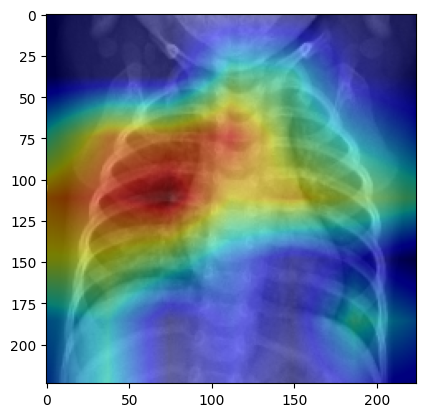

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import BinaryScore

gradcam = Gradcam(model)

img = images[0]

heatmap = gradcam(
    BinaryScore(1),
    img[np.newaxis]
)

plt.imshow(img)

plt.imshow(heatmap[0], cmap='jet', alpha=0.5)

plt.show()